# Week 5 — Day 2: XGBoost Tuning

## Goal
Improve on Day 1 XGBoost baseline using early stopping and
hyperparameter tuning. Target: below 0.14 on Kaggle.

---

## Task 1 — Early Stopping

Set n_estimators=2000 and let early stopping find the best round.

```python
xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=50
)
```

**Result:**
- Best iteration: 1070 of 2000
- Best val RMSE: 0.1301
- 930 trees saved — early stopping prevented overfitting

**Key insight:** early_stopping_rounds goes in the constructor,
not in fit(). Model stops when val RMSE doesn't improve for 50
consecutive rounds.

---

## Task 2 — RandomizedSearchCV Tuning

Searched over 20 random combinations from param grid:

```python
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'n_estimators': [500, 1000, 1500]
}
```

**Best params found:**
| Param | Value |
|---|---|
| learning_rate | 0.01 |
| n_estimators | 1000 |
| max_depth | 5 |
| subsample | 0.7 |
| colsample_bytree | 0.6 |

**Best CV RMSE: 0.1220**

**What each param controls:**
- learning_rate=0.01 — slow learner, needs more trees but generalizes better
- max_depth=5 — medium depth, captures complexity without overfitting
- subsample=0.7 — uses 70% of rows per tree, adds randomness
- colsample_bytree=0.6 — uses 60% of features per tree, reduces correlation

---

## Task 3 — Learning Curves

Plotted train RMSE vs val RMSE across all boosting rounds.

```python
evals = best_model.evals_result()
plt.plot(evals['validation_0']['rmse'], label='Train RMSE')
plt.plot(evals['validation_1']['rmse'], label='Val RMSE')
```

**Observation:** Val RMSE flattens after round ~400.
Model learned most useful patterns in first 400 rounds.
Rounds 400–1000 added minimal value — early stopping
correctly identified this.

**Overfitting signal:** Train RMSE keeps dropping after round 400
but val RMSE flattens — classic overfitting zone. Early stopping
saves us from this automatically.

---

## Task 4 — Kaggle Submission

```python
preds = best_model.predict(X_test_t)
preds_actual = np.expm1(preds)  # reverse log1p transform
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': preds_actual})
submission.to_csv('submission_xgb_tuned.csv', index=False)
```

**Kaggle leaderboard score: 0.12933 ✅**

---

## Progress Table

| Model | RMSE |
|---|---|
| Random Forest baseline | 0.1315 |
| XGBoost early stopping | 0.1301 |
| XGBoost tuned CV | 0.1220 |
| Kaggle submission | 0.12933 |

---

## Key Takeaways
- Early stopping finds optimal n_estimators automatically — always use it
- learning_rate and n_estimators are inversely related — lower LR needs more trees
- Val RMSE flattening = model has learned everything useful
- RandomizedSearchCV with n_iter=20 is fast enough for daily tuning
- Always reverse log1p with expm1 before submitting predictions
- Current standing: top 25% on Kaggle leaderboard
- Next: LightGBM Day 3 — expect further RMSE improvement

# Early stopping:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# load and engineer features
train = pd.read_csv('house_prices_train.csv')
test  = pd.read_csv('house_prices_test.csv')

def engineer_features(df):
    df = df.copy()
    df['TotalSF']     = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath']   = (df['FullBath'] + 0.5*df['HalfBath'] +
                         df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
    df['HouseAge']    = df['YrSold'] - df['YearBuilt']
    df['RemodAge']    = df['YrSold'] - df['YearRemodAdd']
    df['HasPool']     = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']   = (df['GarageArea'] > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

X = train_fe.drop(columns=['SalePrice', 'Id'])
y = np.log1p(train['SalePrice'])

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# preprocessor
num_tr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_tr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_tr, num_cols),
    ('cat', cat_tr, cat_cols)
])

# split for early stopping — needs separate val set
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

# preprocess
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)

# XGBoost with early stopping
# fix — put early_stopping_rounds in constructor, not fit()
xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    verbosity=0,
    early_stopping_rounds=50   # ← move here
)

xgb.fit(
    X_train_t, y_train,
    eval_set=[(X_train_t, y_train), (X_val_t, y_val)],
    verbose=False              # ← remove early_stopping_rounds from here
)

print("=" * 50)
print("   EARLY STOPPING RESULTS")
print("=" * 50)
print(f"  Best iteration : {xgb.best_iteration}")
print(f"  Best val RMSE  : {xgb.best_score:.4f}")
print(f"  Trees used     : {xgb.best_iteration} of 2000")
print("=" * 50)

   EARLY STOPPING RESULTS
  Best iteration : 1070
  Best val RMSE  : 0.1301
  Trees used     : 1070 of 2000


# RandomizedSearchCV tuning:

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'n_estimators': [500, 1000, 1500]
}

xgb_model = XGBRegressor(random_state=42, verbosity=0)

search = RandomizedSearchCV(
    xgb_model, param_grid,
    n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1
)
search.fit(X_train_t, y_train)

print("=" * 50)
print("   TUNED XGBOOST")
print("=" * 50)
print(f"  Best score  : {-search.best_score_:.4f}")
print(f"  Best params : {search.best_params_}")
print("=" * 50)

   TUNED XGBOOST
  Best score  : 0.1220
  Best params : {'subsample': 0.7, 'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


# Plot learning curves:

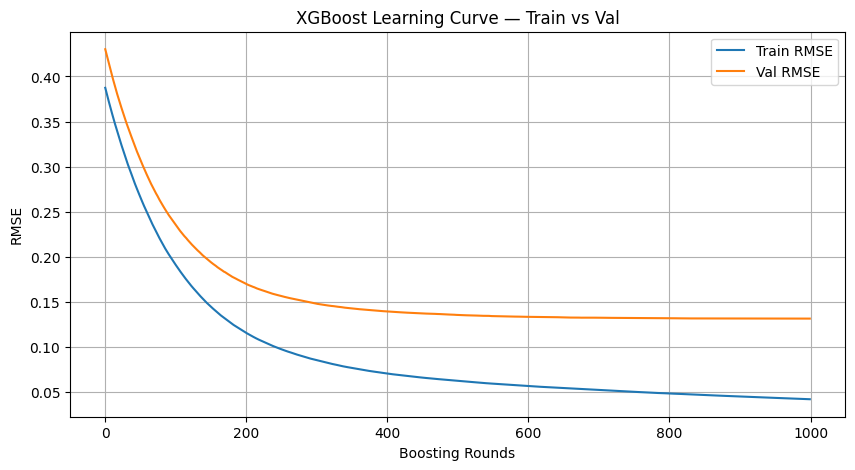

In [3]:
# train final model with best params and plot train vs val loss
results = {}  # store eval results here

best_model = XGBRegressor(
    **search.best_params_,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

best_model.fit(
    X_train_t, y_train,
    eval_set=[(X_train_t, y_train), (X_val_t, y_val)],
    verbose=False
)

# extract results and plot
evals = best_model.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(evals['validation_0']['rmse'], label='Train RMSE')
plt.plot(evals['validation_1']['rmse'], label='Val RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve — Train vs Val')
plt.legend()
plt.grid(True)
plt.savefig('learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Submit to Kaggle:

In [8]:
# preprocess test data
X_test = test_fe.drop(columns=['Id'])
X_test_t = preprocessor.transform(X_test)

# predict
preds = best_model.predict(X_test_t)

# reverse log1p transform
preds_actual = np.expm1(preds)

# create submission
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': preds_actual
})

submission.to_csv('submission_xgb_tuned.csv', index=False)
print(submission.head())
print(f"Submission shape: {submission.shape}")

     Id      SalePrice
0  1461  122656.789062
1  1462  160993.156250
2  1463  183584.656250
3  1464  189469.937500
4  1465  188126.921875
Submission shape: (1459, 2)
